# Programming Assignment 1: Recommender System
### Coure: CS373
#### Developer 1: Jalin A. Brown
#### Developer 2: Sandeep Durga
#### File: 02_cluster_knn.ipynb

### Part Two: Matrix Factorization

1. Implement SVD-based matrix factorization:
- Use scipy.sparse.linalg.svds or sklearn.decomposition.TruncatedSVD
- Choose the factors to test with
- Handle missing values by filling with user means before applying SVD
- Reconstruct matrix
2. Compare matrix factorization methods:
- Plot RMSE vs number of factors for SVD
- Compare with best cluster-based KNN result from part 1
- Document computational time differences
- Identify optimal dimensionality for each method

### 1: Implement SVD-based matrix factorization:

In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse.linalg import svds
from sklearn.decomposition import TruncatedSVD

# Import the MovieLens 100k training and test data sets
# Currently using the first fold split of data of user.base computed as u1_base and u1_test
u1_base_mat = pd.read_csv("../data/u1.base", names=["user_id","item_id","rating","timestamp"], sep="\t", )
u1_test_mat = pd.read_csv("../data/u1.test", names=["user_id","item_id","rating","timestamp"], sep="\t")
print(u1_base_mat.head())
print(f"\nTraining data shape: {u1_base_mat.shape}\n")


print(u1_test_mat.head())
print(f"\nTest data shape: {u1_test_mat.shape}\n")

# Create user-item matrix (excluding possible duplicates or non integers)
users = u1_base_mat["user_id"].astype(int).unique()
items = u1_base_mat["item_id"].astype(int).unique()
user_item_training_matrix = pd.DataFrame(np.nan, index=users, columns=items)

# Fill cells with ratings
for row in u1_base_mat.itertuples(index = False):
    user_item_training_matrix.loc[row.user_id, row.item_id] = row.rating

user_item_training_matrix


   user_id  item_id  rating  timestamp
0        1        1       5  874965758
1        1        2       3  876893171
2        1        3       4  878542960
3        1        4       3  876893119
4        1        5       3  889751712

Training data shape: (80000, 4)

   user_id  item_id  rating  timestamp
0        1        6       5  887431973
1        1       10       3  875693118
2        1       12       5  878542960
3        1       14       5  874965706
4        1       17       3  875073198

Test data shape: (20000, 4)



,1,2,3,4,5,7,8,9,11,13,...,1674,1675,1676,1677,1678,1679,1680,907,1681,1682
1,5.0,3.0,4.0,3.0,3.0,4.0,1.0,5.0,2.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
939,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
940,NaN,NaN,NaN,2.0,NaN,4.0,5.0,3.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
941,5.0,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
942,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Handle missing values by filling with user means before applying SVD
user_means_mat = user_item_training_matrix.mean(axis=1)
filled_user_means_mat = user_item_training_matrix.T.fillna(user_means_mat).T

print(filled_user_means_mat)

         1         2         3         4         5         7         8     \
1    5.000000  3.000000  4.000000  3.000000  3.000000  4.000000  1.000000   
2    4.000000  3.800000  3.800000  3.800000  3.800000  3.800000  3.800000   
3    3.000000  3.000000  3.000000  3.000000  3.000000  3.000000  3.000000   
4    4.357143  4.357143  4.357143  4.357143  4.357143  4.357143  4.357143   
5    2.956044  2.956044  2.956044  2.956044  2.956044  2.956044  2.956044   
..        ...       ...       ...       ...       ...       ...       ...   
939  4.265306  4.265306  4.265306  4.265306  4.265306  4.265306  4.265306   
940  3.457944  3.457944  3.457944  2.000000  3.457944  4.000000  5.000000   
941  5.000000  4.045455  4.045455  4.045455  4.045455  4.000000  4.045455   
942  4.265823  4.265823  4.265823  4.265823  4.265823  4.265823  4.265823   
943  3.410714  5.000000  3.410714  3.410714  3.410714  3.410714  3.410714   

         9         11        13    ...      1674      1675      1676  \
1  

In [4]:
# Choose the factors to test with latent dimensions
ranks_to_test = [5, 10, 20, 40, 60, 80, 100]
print("Ranks to test:", ranks_to_test)

Ranks to test: [5, 10, 20, 40, 60, 80, 100]


In [5]:
# Implement matrix factorization
rating_matrix = filled_user_means_mat.values
users = list(filled_user_means_mat.index)
items = list(filled_user_means_mat.columns)

# Mapping for users and item cells
user_index = {u: i for i, u in enumerate(users)}
item_index = {i: u for i, u in enumerate(items)}

# Store results
rmse_per_rank = []
time_per_rank = []

print("RMSE for various latent factors:\n")
for rank in ranks_to_test:
    start_time = time.time()

    # low-rank SVD decomp
    U, sigma, Vt = svds(rating_matrix, k=rank, which='LM')

    # Convert Sigma to diag matrix
    Sigma = np.diag(sigma)

    # Reconstruct the rating matrix using the latent factors
    svd_matrix = np.dot(np.dot(U, Sigma), Vt)

    # Record computational time
    elapsed_time = time.time() - start_time

    # Compute RMSE
    square_error_sum = 0.0
    count = 0

    for row in u1_test_mat.itertuples(index = False):
        users = row.user_id
        items = row.item_id

        # evaluate overlapping users/items
        if (users in user_index) and (items in item_index):
            predicted_rating = svd_matrix[user_index[users], item_index[items]]
            error = row.rating - predicted_rating
            square_error_sum += error * error
            count += 1
    rmse = np.sqrt(square_error_sum / count)
    rmse_per_rank.append(rmse)
    time_per_rank.append(elapsed_time)

    print(f"Latent factors = {rank:3d}\n, RMSE = {rmse:.4f}\n, RMSE_per_rank = {rmse_per_rank}\n, Time = {elapsed_time:.4f} seconds")

RMSE for various latent factors:

Latent factors =   5
, RMSE = 1.0670
, RMSE_per_rank = [1.0670106221321338]
, Time = 0.1601 seconds
Latent factors =  10
, RMSE = 1.0733
, RMSE_per_rank = [1.0670106221321338, 1.0732992348349604]
, Time = 0.2072 seconds
Latent factors =  20
, RMSE = 1.0766
, RMSE_per_rank = [1.0670106221321338, 1.0732992348349604, 1.0765849479192602]
, Time = 0.7730 seconds
Latent factors =  40
, RMSE = 1.0823
, RMSE_per_rank = [1.0670106221321338, 1.0732992348349604, 1.0765849479192602, 1.0823339083791117]
, Time = 0.6098 seconds
Latent factors =  60
, RMSE = 1.0883
, RMSE_per_rank = [1.0670106221321338, 1.0732992348349604, 1.0765849479192602, 1.0823339083791117, 1.0883025978917633]
, Time = 1.0803 seconds
Latent factors =  80
, RMSE = 1.0938
, RMSE_per_rank = [1.0670106221321338, 1.0732992348349604, 1.0765849479192602, 1.0823339083791117, 1.0883025978917633, 1.0937883411295657]
, Time = 1.0775 seconds
Latent factors = 100
, RMSE = 1.0977
, RMSE_per_rank = [1.06701062

For each rank we have computed a low-rank SVD of the user mean filled matrix, reconstructed the approximation, and timed the operation. Then we score only the user-item pairs that appear both in u1.test AND exist in our training matrix. Thus building a RMSE report, as number of latent factors increases.

# 2. Compare matrix factorization methods:

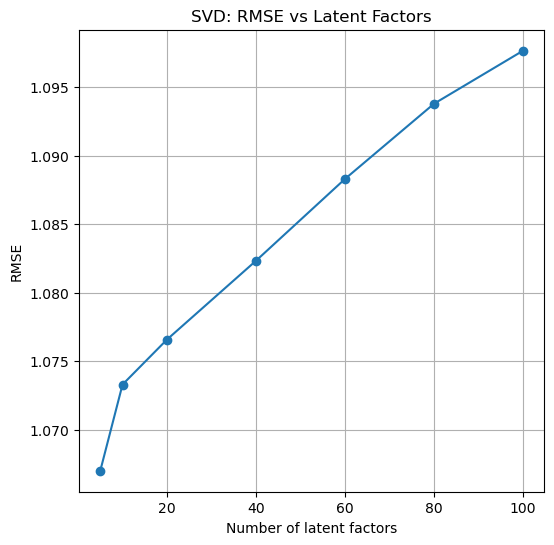

In [6]:
# Plot RMSE for number of factors for SVD

plt.figure(figsize = (6,6))
plt.plot(ranks_to_test, rmse_per_rank, marker="o")
plt.xlabel("Number of latent factors")
plt.ylabel("RMSE")
plt.title("SVD: RMSE vs Latent Factors")
plt.grid(True)
plt.show()


The RMSE increases as factors grow. Higher ranks introduce more noise.

In [7]:
# Document computational time differences
timing_df = pd.DataFrame({
    "rank": ranks_to_test,
    "time (seconds)": time_per_rank,
    "RMSE": rmse_per_rank
})
display(timing_df)

,rank,time (seconds),RMSE
0,5,0.160126,1.067011
1,10,0.207202,1.073299
2,20,0.772980,1.076585
3,40,0.609836,1.082334
4,60,1.080295,1.088303
5,80,1.077479,1.093788
6,100,1.636960,1.097655


Runtime also grows with the number of factors. This runtime is still a lot faster than KNN clustering. RMSE will be compared along with runtime to prove this.

In [8]:
# Identify best number of latent factors for SVD

best_index = timing_df["RMSE"].idxmin()
best_rank = int(timing_df.loc[best_index]["rank"])
best_rmse = float(timing_df.loc[best_index]["RMSE"])
best_time = float(timing_df.loc[best_index]["time (seconds)"])

print(f"Best SVD latency factor (by RMSE) rank = {best_rank}  with RMSE={best_rmse:.4f}, with time={best_time:.4f}")

Best SVD latency factor (by RMSE) rank = 5  with RMSE=1.0670, with time=0.1601


#### ^ All code up to this point written by Jalin A. Brown ^

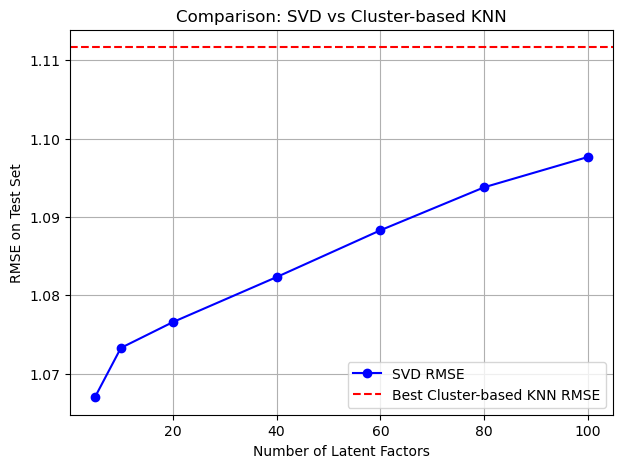

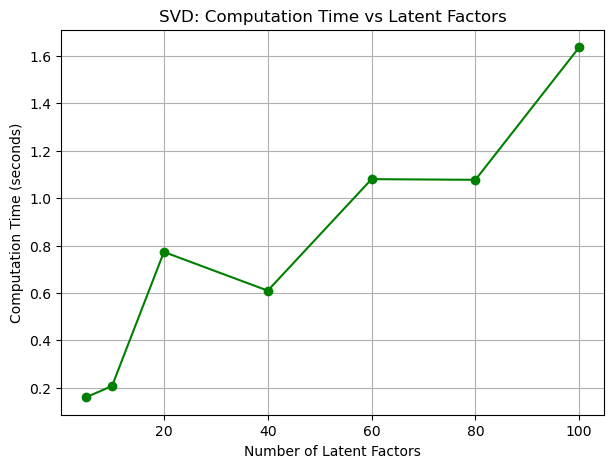

,Rank (latent factors),RMSE,Time (seconds)
0,5,1.067011,0.160126
1,10,1.073299,0.207202
2,20,1.076585,0.772980
3,40,1.082334,0.609836
4,60,1.088303,1.080295
5,80,1.093788,1.077479
6,100,1.097655,1.636960


 Best SVD latent factor (by RMSE): 5
RMSE = 1.0670, Time = 0.1601 seconds
Comparison: Cluster-based KNN RMSE = 1.1116


In [12]:
best_cluster_rmse = 1.111644 

# --- Plot RMSE vs number of factors for SVD and compare with best Cluster-based CF ---
plt.figure(figsize=(7,5))
plt.plot(ranks_to_test, rmse_per_rank, marker='o', linestyle='-', color='blue', label='SVD RMSE')
plt.axhline(y=best_cluster_rmse, color='red', linestyle='--', label='Best Cluster-based KNN RMSE')
plt.xlabel("Number of Latent Factors")
plt.ylabel("RMSE on Test Set")
plt.title("Comparison: SVD vs Cluster-based KNN")
plt.grid(True)
plt.legend()
plt.show()

# --- Plot computation time vs number of factors ---
plt.figure(figsize=(7,5))
plt.plot(ranks_to_test, time_per_rank, marker='o', linestyle='-', color='green')
plt.xlabel("Number of Latent Factors")
plt.ylabel("Computation Time (seconds)")
plt.title("SVD: Computation Time vs Latent Factors")
plt.grid(True)
plt.show()

# --- Summary Table ---
timing_df = pd.DataFrame({
    "Rank (latent factors)": ranks_to_test,
    "RMSE": rmse_per_rank,
    "Time (seconds)": time_per_rank
})
display(timing_df)

# --- Optimal number of latent factors ---
best_index = timing_df["RMSE"].idxmin()
best_rank = int(timing_df.loc[best_index]["Rank (latent factors)"])
best_rmse = float(timing_df.loc[best_index]["RMSE"])
best_time = float(timing_df.loc[best_index]["Time (seconds)"])

print(f" Best SVD latent factor (by RMSE): {best_rank}")
print(f"RMSE = {best_rmse:.4f}, Time = {best_time:.4f} seconds")
print(f"Comparison: Cluster-based KNN RMSE = {best_cluster_rmse:.4f}")
